## Máster en Big Data y Data Science

### Metodologías de gestión y diseño de proyectos de big data

#### AP2 - Modelado y evaluación

---

En esta libreta se realiza la experimentación para generación del modelo de predicción objetivo del proyecto y la evaluación del mismo.
La versión del dataset a utilizar es la obtenida a partir de las operaciones de transformación.

In [1]:
# Se importan las librerías necesarias y se suprimen las advertencias
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.dummy import DummyClassifier

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore',category=FutureWarning)
warnings.filterwarnings('ignore',category=UserWarning)

Incorporamos MLFlow

In [2]:
import mlflow
import mlflow.sklearn
from datetime import datetime

mlflow.set_tracking_uri("file:./mlruns")
mlflow.set_experiment("13MBID-Experimentación original (MVP modificado con Undersampling)")

<Experiment: artifact_location='file:c:/13MBID/13MBID-OCT2526/notebooks/mlruns/240654256045397460', creation_time=1776607000098, experiment_id='240654256045397460', last_update_time=1776607000098, lifecycle_stage='active', name='13MBID-Experimentación original (MVP modificado con Undersampling)', tags={}, trace_location=None, workspace='default'>

In [3]:
# Lectura de los datos
df = pd.read_csv('../data/processed/datos_integrados.csv')
df.head(5)

,edad,antiguedad_empleado,situacion_vivienda,ingresos,objetivo_credito,pct_ingreso,tasa_interes,estado_credito,falta_pago,antiguedad_cliente,...,estado_cliente,genero,limite_credito_tc,nivel_educativo,personas_a_cargo,capacidad_pago,presion_financiera,gasto_promedio_operacion,operaciones_mensuales_tc,estabilidad_laboral
0,22,123.0,ALQUILER,59000,PERSONAL,0.59,16.02,1,Y,36.0,...,ACTIVO,M,4010.0,UNIVERSITARIO_COMPLETO,2.0,0.593220,0.216181,45.333333,2.000000,5.590909
1,21,5.0,PROPIA,9600,EDUCACIÓN,0.10,11.14,0,N,39.0,...,ACTIVO,M,12691.0,SECUNDARIO_COMPLETO,3.0,0.104167,0.171250,27.238095,3.500000,0.238095
2,25,1.0,HIPOTECA,9600,SALUD,0.57,12.87,1,N,44.0,...,ACTIVO,F,8256.0,UNIVERSITARIO_COMPLETO,5.0,0.572917,0.325451,39.121212,2.750000,0.040000
3,23,4.0,ALQUILER,65500,SALUD,0.53,15.23,1,N,36.0,...,ACTIVO,M,3418.0,UNIVERSITARIO_COMPLETO,3.0,0.534351,0.295985,94.350000,1.666667,0.173913
4,24,8.0,ALQUILER,54400,SALUD,0.55,14.27,1,Y,54.0,...,ACTIVO,M,9095.0,DESCONOCIDO,1.0,0.643382,0.185000,50.538462,2.166667,0.333333


In [4]:
def reporte_descripcion_dataset(df):
    columnas = df.columns
    print("Columnas del dataset:\n")
    for col in columnas:
        print(col)
    print(f"\nCantidad de filas: {df.shape[0]}")

print("Descripción del dataset 'datos_integrados.csv':\n")
reporte_descripcion_dataset(df)

Descripción del dataset 'datos_integrados.csv':

Columnas del dataset:

edad
antiguedad_empleado
situacion_vivienda
ingresos
objetivo_credito
pct_ingreso
tasa_interes
estado_credito
falta_pago
antiguedad_cliente
estado_civil
estado_cliente
genero
limite_credito_tc
nivel_educativo
personas_a_cargo
capacidad_pago
presion_financiera
gasto_promedio_operacion
operaciones_mensuales_tc
estabilidad_laboral

Cantidad de filas: 10123


In [5]:
# Se divide el dataset en variables predictoras y variable objetivo
target = "falta_pago"

features_X = df.drop(columns=[target])
labels_y = df[target]

print("Dimensiones X:", features_X.shape)
print("Dimensiones y:", labels_y.shape)

Dimensiones X: (10123, 20)
Dimensiones y: (10123,)


In [6]:
# Se genera el conjunto de entrenamiento, validación y test con estratificación

# Primero separar test final (10%)
X_temp, X_test, y_temp, y_test = train_test_split(
    features_X,
    labels_y,
    test_size=0.10,
    random_state=42,
    stratify=labels_y
)

# Luego separar train y validation (22% del 90% es aprox. el 20% del total)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.22,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (7105, 20)
Validation: (2005, 20)
Test: (1013, 20)


In [7]:
# Se identifican las columnas numéricas y categóricas

num_cols = features_X.select_dtypes(include=["int64","float64"]).columns.tolist()
cat_cols = features_X.select_dtypes(include=["object","category"]).columns.tolist()

print("Numéricas:", num_cols)
print("Categóricas:", cat_cols)

Numéricas: ['edad', 'antiguedad_empleado', 'ingresos', 'pct_ingreso', 'tasa_interes', 'estado_credito', 'antiguedad_cliente', 'limite_credito_tc', 'personas_a_cargo', 'capacidad_pago', 'presion_financiera', 'gasto_promedio_operacion', 'operaciones_mensuales_tc', 'estabilidad_laboral']
Categóricas: ['situacion_vivienda', 'objetivo_credito', 'estado_civil', 'estado_cliente', 'genero', 'nivel_educativo']


In [8]:
# Se verifica la distribución de la variable objetivo en el conjunto de entrenamiento
y_train.value_counts()

falta_pago
N    5864
Y    1241
Name: count, dtype: int64

In [9]:
# Se crea un pipeline para preprocesamiento de datos

numeric_transformer = Pipeline([
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

In [10]:
# Se crea un pipeline completo con preprocesamiento y modelo base

baseline = Pipeline([
    ("prep", preprocessor),
    ("model", DummyClassifier(strategy="most_frequent"))
])

baseline.fit(X_train, y_train)

y_pred = baseline.predict(X_val)

print("Baseline accuracy:", accuracy_score(y_val, y_pred))

Baseline accuracy: 0.8254364089775561


In [11]:
# Se definen los modelos a evaluar

modelos = {
    "LogisticRegression": LogisticRegression(max_iter=2000),
    "LinearSVC": LinearSVC(max_iter=5000),
    "KNN": KNeighborsClassifier(),
    "DecisionTree": DecisionTreeClassifier(random_state=42)
}

Valor Original + Modificación inicial

In [ ]:
# # Se evaluan los modelos con validación cruzada comparando sus resultados
# from imblearn.pipeline import Pipeline as ImbPipeline
# from imblearn.under_sampling import RandomUnderSampler
# from sklearn.model_selection import cross_validate

# resultados = []

# for nombre, modelo in modelos.items():
#     # Se aplica el preprocesamiento
#     pipeline = ImbPipeline([
#         ("prep", preprocessor),
#         ("undersample", RandomUnderSampler(random_state=42)),
#         ("model", modelo)
#     ])

#     # Se evalúan los modelos con validación cruzada
#     scores = cross_validate(
#         pipeline,
#         X_train,
#         y_train,
#         cv=5,
#         scoring=["accuracy", "precision", "recall", "f1", "roc_auc"]
#     )

#     # Se almacenan los resultados
#     resultados.append({
#         "modelo": nombre,
#         "accuracy": scores["test_accuracy"].mean(),
#         "precision": scores["test_precision"].mean(),
#         "recall": scores["test_recall"].mean(),
#         "f1": scores["test_f1"].mean(),
#         "roc_auc": scores["test_roc_auc"].mean(),
#     })

# df_resultados = pd.DataFrame(resultados)

# df_resultados.sort_values("roc_auc", ascending=False)

Valor modificado al integrar MLFlow

In [12]:
# Se evaluan los modelos con validación cruzada comparando sus resultados
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import cross_validate
from sklearn.metrics import f1_score, recall_score, precision_score, roc_auc_score
from mlflow.models import infer_signature
import numpy as np

# Función auxiliar para obtener un score continuo y poder calcular ROC AUC.
# Se prioriza `predict_proba` y, si el modelo no lo soporta, se usa `decision_function`.
def _score_for_auc(estimator, X):
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(X)[:, 1]
    if hasattr(estimator, "decision_function"):
        return estimator.decision_function(X)
    return None

# Scorers personalizados para evitar métricas `NaN` cuando un modelo no predice
# la clase positiva en algún fold de validación cruzada.
def _cv_precision(estimator, X, y):
    return precision_score(y, estimator.predict(X), zero_division=0)

def _cv_recall(estimator, X, y):
    return recall_score(y, estimator.predict(X), zero_division=0)

def _cv_f1(estimator, X, y):
    return f1_score(y, estimator.predict(X), zero_division=0)

# Se convierte la variable objetivo una sola vez y fuera del loop.
# Cambio realizado: así se evita modificar `y_train`, `y_val` y `y_test`
# en cada iteración de modelos.
if set(y_train.dropna().unique()) == {"N", "Y"}:
    y_train_eval = y_train.map({"N": 0, "Y": 1})
    y_val_eval = y_val.map({"N": 0, "Y": 1})
    y_test_eval = y_test.map({"N": 0, "Y": 1})
else:
    y_train_eval = y_train.copy()
    y_val_eval = y_val.copy()
    y_test_eval = y_test.copy()

def evaluar_y_registrar_mlflow(nombre, modelo):
    # Se arma un pipeline con preprocesamiento, undersampling y el modelo a evaluar
    pipeline = ImbPipeline([
            ("prep", preprocessor),
            ("undersample", RandomUnderSampler(random_state=42)),
            ("model", modelo)
        ])

    # Se evalúan los modelos con validación cruzada
    # Cambio realizado: se usan scorers personalizados para precision, recall y f1,
    # evitando valores indefinidos en validación cruzada.
    scores = cross_validate(
        pipeline,
        X_train,
        y_train_eval, # Cambio realizado: se usa `y_train_eval` con valores numéricos para la evaluación.
        cv=5,
        scoring={
            "accuracy": "accuracy",
            "precision": _cv_precision,
            "recall": _cv_recall,
            "f1": _cv_f1,
            "roc_auc": "roc_auc"
        }
    )

    # Se entrena el pipeline completo con todos los datos de entrenamiento.
    pipeline.fit(X_train, y_train_eval)

    # Predicciones y scores sobre test.
    y_test_pred = pipeline.predict(X_test)
    y_test_score = _score_for_auc(pipeline, X_test)
    test_roc_auc = roc_auc_score(y_test_eval, y_test_score) if y_test_score is not None else np.nan

    # Se infiere la firma del modelo para registrar correctamente en MLflow.
    signature = infer_signature(X_train, pipeline.predict(X_train))

    with mlflow.start_run(run_name=f"Evaluación {nombre}"):
        # Se registran los hiperparámetros del modelo.
        mlflow.log_params(modelo.get_params())

        # Se registran parámetros adicionales del experimento.
        mlflow.log_params({
            "train_samples": len(X_train),
            "validation_samples": len(X_val),
            "test_samples": len(X_test),
            "balancing_method": "undersampling",
            "cv_folds": 5
        })

        # Métricas promedio y desvío estándar de validación cruzada.
        mlflow.log_metrics({
            "cv_accuracy_mean": scores["test_accuracy"].mean(),
            "cv_precision_mean": scores["test_precision"].mean(),
            "cv_recall_mean": scores["test_recall"].mean(),
            "cv_f1_mean": scores["test_f1"].mean(),
            "cv_roc_auc_mean": scores["test_roc_auc"].mean(),
            "cv_accuracy_std": scores["test_accuracy"].std(),
            "cv_precision_std": scores["test_precision"].std(),
            "cv_recall_std": scores["test_recall"].std(),
            "cv_f1_std": scores["test_f1"].std(),
            "cv_roc_auc_std": scores["test_roc_auc"].std()
        })

        mlflow.log_metrics({
            "test_accuracy": accuracy_score(y_test_eval, y_test_pred),
            "test_precision": precision_score(y_test_eval, y_test_pred, zero_division=0),
            "test_recall": recall_score(y_test_eval, y_test_pred, zero_division=0),
            "test_f1": f1_score(y_test_eval, y_test_pred, zero_division=0),
            "test_roc_auc": test_roc_auc
        })

        # Se registra el modelo entrenado en MLflow.
        mlflow.sklearn.log_model(
            pipeline,
            artifact_path="model",
            signature=signature
        )

        print(f"Modelo {nombre} evaluado y registrado en MLflow.")

        # Se devuelve un resumen para construir la tabla comparativa final.
    return {
        "modelo": nombre,
        "accuracy": scores["test_accuracy"].mean(),
        "precision": scores["test_precision"].mean(),
        "recall": scores["test_recall"].mean(),
        "f1": scores["test_f1"].mean(),
        "roc_auc": scores["test_roc_auc"].mean()
    }

resultados = []

for nombre, modelo in modelos.items():
    resultados.append(evaluar_y_registrar_mlflow(nombre, modelo))

df_resultados = pd.DataFrame(resultados)
df_resultados.sort_values("roc_auc", ascending=False)

2026/05/01 11:30:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/01 11:30:35 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Modelo LogisticRegression evaluado y registrado en MLflow.


2026/05/01 11:31:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/01 11:31:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Modelo LinearSVC evaluado y registrado en MLflow.


2026/05/01 11:31:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/01 11:31:35 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Modelo KNN evaluado y registrado en MLflow.


2026/05/01 11:31:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/01 11:31:53 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Modelo DecisionTree evaluado y registrado en MLflow.


,modelo,accuracy,precision,recall,f1,roc_auc
0,LogisticRegression,0.845742,0.537555,0.846901,0.657545,0.923587
1,LinearSVC,0.846868,0.540015,0.842871,0.658141,0.923211
2,KNN,0.802674,0.463741,0.813898,0.590583,0.881042
3,DecisionTree,0.826460,0.502637,0.801791,0.617710,0.816737


In [13]:
# Se entrena el mejor modelo

modelo_final = Pipeline([
    ("prep", preprocessor),
    #("model", LinearSVC(max_iter=5000)) -- ORIGINAL
    ("model", LogisticRegression(max_iter=2000))
])

modelo_final.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

In [14]:
# Se evalúan los resultados en el conjunto de validación

y_val_pred = modelo_final.predict(X_val)

print(classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

           N       0.92      0.95      0.93      1655
           Y       0.72      0.60      0.65       350

    accuracy                           0.89      2005
   macro avg       0.82      0.78      0.79      2005
weighted avg       0.88      0.89      0.88      2005



In [15]:
# Se evalúan los resultados en el conjunto de test

y_test_pred = modelo_final.predict(X_test)

print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           N       0.92      0.94      0.93       836
           Y       0.71      0.62      0.66       177

    accuracy                           0.89      1013
   macro avg       0.81      0.78      0.80      1013
weighted avg       0.88      0.89      0.89      1013



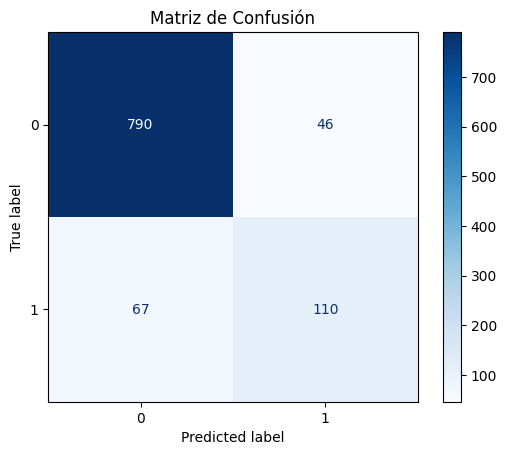

In [16]:
# Se genera una matriz de confusión para el conjunto de test

cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("Matriz de Confusión")
plt.show()

In [17]:
df_resultados.to_csv("resultados_modelos.csv", index=False)